<p>
<h1><b><center></center></b></h1>
<center><img src="https://drive.google.com/uc?id=1UJc1ci41G6ahJ7ProKvunUOIBcTXZ6ZG" align="center" width="550"></center>
</p>
<h1><b><center>Mecánica Celeste</center></b></h1>
<h2><b><center>Prof. Jorge I. Zuluaga</center></b></h1>
<h2><b><center>Proyecto del Curso</center></b><h2>
<h3><b><center>Disco de acreción alrededor de un agujero negro</center></b><h3>
<h7><center><i>Última actualización del profesor</b>: Viernes 20 de marzo de 2026, 2:00 pm</i></center><h7>
</p>

## Enunciado

<center>
<img src="https://cdn.sci.news/images/2021/02/image_9386-AT2019dsg.jpg" align="center" width="100%"></center>

Muchos objetos astrofísicos fascinantes (núcleos galácticos activos, hipernovas, binarias de rayos X) pueden explicarse con los fenómenos que ocurren en los denominados discos de acreción alrededor de agujeros negros. En este proyecto usaremos lo visto en el curso de Relatividad y Gravitación para estudiar esos fenómenos.

El objetivo de este trabajo es desarrollar simulaciones, cálculos útiles, predicciones sobre el comportamiento de las partículas en un disco de acreción. La idea es poner en práctica lo visto en el curso, tanto en las partes de relatividad especial como en las de relatividad general, para estudiar estos sistemas.

## Algunas ideas

Existen muchas maneras de aplicar la teoría que veremos en el curso en este problema y no queremos sesgar tu elección de los temas o cálculos que quieras escoger para aplicarla. Sin embargo aquí van algunas ideas de cálculos que se podrían hacer:
- Simulación del movimiento de muchas partículas alrededor del agujero negro usando, inicialmente, la dinámica newtoniana.
- Cálculo y representación gráfica de la luz emitida por el disco y observada desde distinto ángulos, incluyendo los efectos de beaming y desplazamiento espectral.
- Simulación del jet del agujero negro usando partículas cargadas moviéndose en el campo del jet.
- Cálculo de la trayectoria de fotones para visualizar el disco de acreción desde distintos ángulos.
- Cálculo de las trayectorias de partículas usando la métrica de Schwarzschild y de Kerr.

## Entregables

El entregable del proyecto es **un notebook final de Jupyter** con una descripción de la teoría básica que uses, los experimentos numéricos que hayas realizado y las conclusiones a las que llegues con esos experimentos. Por supuesto puedes desarrollar otros programas y notebooks paralelos, pero se revisará el notebook con el reporte final.

Adicionalmente se deberá entregar **un repositorio de GitHub** que tenga todos los archivos, datos, notebooks, programas usados para este propósito. El notebook debe estar alojado en el repositorio.

## Criterios de evaluación

Una vez entregues el proyecto el profesor realizará una revisión del mismo y te lo devolverá con observaciones. En la segunda revisión emitirá un concepto cuantitativo del proyecto. Los criterios a evaluar serán:

- Correcta descripción y aplicación de la teoría.
- Originalidad de los experimentos numéricos.
- Conclusiones derivadas de los experimentos.
- Organización y extensión del reporte final.
- Ritmo de actualizaciones del repositorio de GitHub.

## Para tener en cuenta

- La solución presentada debe ser estrictamente individual. Evite resolver la tarea en parejas o en grupos que puede conducir a códigos o soluciones idénticos o muy similares.
- Los métodos y herramientas para resolver el problema deben ser los vistos en clase. El uso de herramientas diferentes puede ser una buena práctica en el mundo académico o laboral, pero en un curso puede también ser un indicio de un mal uso de las *asesorías* externa o del uso inapropiado de herramientas de Inteligencia Artificial (IA).
- El notebook entregado debe tener todos los resultados y gráficos, calculados y a la vista.  También debe ejecutarse completamente con `Ejecutar Todo` sin producir ningún error (verifique antes de entregar).
- El notebook debe tener explicaciones detalladas para cada paso del procedimiento usando celdas de texto. No debe poner una celda de código sin explicarla. En caso de incluir ecuaciones debe usar $\LaTeX$.

# **Proyecto Relatividad y Gravitación**

### **María Isabel Olarte García - CC 1034986320**

Librerías a utilizar:

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import pymcel as pc
import rebound as rb
from pymcel import constantes as const
from scipy.integrate import solve_ivp
import plotly.graph_objects as go
import matplotlib.colors as mcolors
import einsteinpy.symbolic as es
import sympy as sp
import spiceypy as spy

## **Movimiento de Partículas con Mecánica Newtoniana**

Creamos una simulación de Rebound

In [41]:
sim = rb.Simulation()
sim.G = 1.0
sim.integrator = "whfast"

Agregamos el agujero negro y las partículas del disco a la simulación. Agregamos $N=300$ partículas con posiciones aleatorias en un disco con $r_{mín}=3$ y $r_{máx}=10$

In [42]:
sim.add(m=1.0) # Agujero Negro

N = 300
r_min = 3
r_max = 10

# Partículas del Disco
for _ in range(N):
    r = np.random.uniform(r_min, r_max)
    phi = np.random.uniform(0, 2*np.pi)
    
    sim.add(
        m=0,
        a=r,
        e=0.0,
        inc=0.0,
        Omega=0.0,
        omega=0.0,
        f=phi
    )

sim.move_to_com()

Visualización del disco obtenido

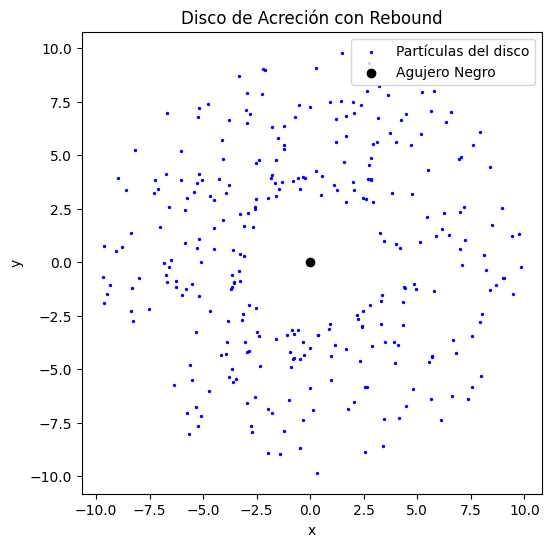

In [43]:
def plot_disk(sim):
    x = [particula.x for particula in sim.particles[1:]]
    y = [particula.y for particula in sim.particles[1:]]
    
    plt.figure(figsize=(6,6))
    plt.scatter(x, y, s=2, color='blue', label='Partículas del disco')
    plt.scatter(0, 0, color='black', label='Agujero Negro')
    plt.gca().set_aspect('equal')
    plt.legend()
    plt.title("Disco de Acreción con Rebound")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()

plot_disk(sim)

Integramos el sistema en el tiempo, guardando para cada partícula su posición en $x$, su posición en $y$ y su velocidad $v$ para cada tiempo

In [44]:
tiempos = np.linspace(0, 80, 250)

xs = np.zeros((250, N))
ys = np.zeros((250, N))
vs = np.zeros((250, N))

for i, t in enumerate(tiempos):
    sim.integrate(t)
    for j in range(N):
        particula = sim.particles[j+1]
        xs[i, j] = particula.x
        ys[i, j] = particula.y
        velocidad = np.sqrt(particula.vx**2 + particula.vy**2)
        vs[i, j] = velocidad

Normalizamos las velocidades para obtener una mejor visualización de la gráfica

In [45]:
vmin = np.min(vs)
vmax = np.max(vs)

Creación de los frames para la figura de plotly

In [46]:
frames = []

for i in range(250):
    frame = go.Frame(
        data=[
            go.Scatter(
                x=xs[i],
                y=ys[i],
                mode='markers',
                marker=dict(
                    size=3,
                    color=vs[i],
                    colorscale='Turbo',
                    cmin=vmin,
                    cmax=vmax,
                    colorbar=dict(
                        title="Velocidad"
                    ),
                ),
            )
        ],
        name=str(i)
    )
    frames.append(frame)

Creamos una figura interactiva con plotly, la cual muestra la animación de las órbitas newtonianas de las partículas, permite avanzar y retroceder en el tiempo mediante un slider y representa la velocidad de las partículas con un mapa de color que va desde la velocidad mínima hasta la velocidad máxima

In [47]:
fig = go.Figure(
    data=[
        # Partículas
        go.Scatter(
            x=xs[0],
            y=ys[0],
            mode='markers',
            marker=dict(
                size=3,
                color=vs[0],
                colorscale='Turbo',
                cmin=vmin,
                cmax=vmax,
                colorbar=dict(title="Velocidad"),
            ),
            showlegend=False,  # Ocultar la leyenda automática de las partículas
        ),
        # Agujero negro
        go.Scatter(
            x=[0],
            y=[0],
            mode='markers',
            marker=dict(
                size=18,
                color='black'
            ),
            name='Agujero negro'
        )
    ],
    frames=frames # Frames definidos en la celda anterior
)

sliders = [
    {
        "steps": [
            {
                "args": [
                    [str(i)],
                    {
                        "frame": {"duration": 0, "redraw": True},
                        "mode": "immediate"
                    }
                ],
                "label": f"{tiempos[i]:.1f}",
                "method": "animate",
            }
            for i in range(250)
        ],
        "transition": {"duration": 0},
        "x": 0.1,
        "len": 0.85,
    }
]

fig.update_layout(
    title="Disco de Acreción con Rebound",
    width=900,
    height=900,
    xaxis=dict(
        range=[-15, 15],
        zeroline=False,
    ),
    yaxis=dict(
        range=[-15, 15],
        scaleanchor="x",
        zeroline=False,
    ),
    template="plotly_dark",
    sliders=sliders,
    legend=dict(
        xanchor="right",
        x=0.98,
        yanchor="top",
        y=0.98
    ),
    updatemenus=[
        {
            "type": "buttons",
            "buttons": [
                {
                    "label": "Play",
                    "method": "animate",
                    "args": [
                        None,
                        {
                            "frame": {
                                "duration": 40,
                                "redraw": True
                            },
                            "fromcurrent": True
                        }
                    ],
                },
                {
                    "label": "Pause",
                    "method": "animate",
                    "args": [
                        [None],
                        {
                            "frame": {
                                "duration": 0,
                                "redraw": False
                            },
                            "mode": "immediate"
                        }
                    ],
                }
            ],
            "direction": "left",
            "pad": {"r": 10, "t": 10},
            "showactive": True,
            "x": 0.1,
            "y": 1.08,
        }
    ]
)

fig.show()

Al simular la dinámica de las partículas del disco de acreción con dinámica newtoniana se observa que todas siguen órbitas circulares y cerradas, con velocidades mayores cerca del agujero negro y menores en la parte exterior del disco.

## **Beaming Relativista**

Para trabajar con beaming relativista, se deben tener en cuenta las siguientes expresiones:

**1. Factor Gamma:** $$\gamma = \frac{1}{\sqrt{1-\beta^2}}$$

**2. Factor de Beaming:** $$\delta(\theta , \beta) = \frac{1}{\gamma (1-\beta \cos(\theta))}$$

**3. Desplazamiento Espectral Cinemático:** $$\nu = \delta (\theta , \beta) \nu_0$$

**4. Desplazamiento Espectral (Al Azul o al Rojo):** $$z=\frac{1}{\delta(\theta , \beta)}-1$$

**5. Aberración Angular:** $$\cos(\theta) = \frac{\cos(\theta ') + \beta}{1 + \beta \cos(\theta ')}$$

A continuación se definen las funciones correspondientes a dichas expresiones:

In [48]:
def gamma_factor(beta):
    return 1 / np.sqrt(1 - beta**2)

def factor_beaming(theta, beta):
    return 1 / (gamma_factor(beta) * (1 - beta * np.cos(theta)))

def desplazamiento_espectral_cinematico(theta, beta, nu0):
    "Devuelve el cambio en la frecuencia debido al movimiento de la fuente"
    return factor_beaming(theta, beta) * nu0

def desplazamiento_espectral(theta, beta):
    "Devuelve el desplazamiento al rojo o al azul"
    return 1/factor_beaming(theta, beta) - 1

def aberracion_angular(theta_prima, beta):
    """Devuelve el ángulo observado en el marco del observador dado el ángulo
    en el marco de la fuente"""
    cos_theta = (np.cos(theta_prima) + beta) / (1 + beta * np.cos(theta_prima))
    return np.arccos(cos_theta)

Factor de Beaming vs Ángulo para distintos $\beta$

Definimos algunos valores de $\beta = \frac{v}{c}$ para determinar cómo varía el factor de beaming en función de $\theta$

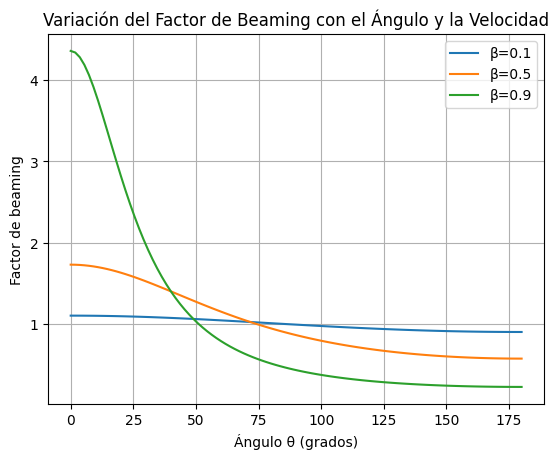

In [49]:
betas = np.array([0.1, 0.5, 0.9])
thetas_rad = np.linspace(0, np.pi, 100)
thetas_deg = np.degrees(thetas_rad)

for index, beta in enumerate(betas):
    factor_beaming_values = factor_beaming(thetas_rad, beta)
    plt.plot(thetas_deg, factor_beaming_values, label=f'β={beta}')

plt.xlabel('Ángulo θ (grados)')
plt.ylabel('Factor de beaming')
plt.title('Variación del Factor de Beaming con el Ángulo y la Velocidad')
plt.legend()
plt.grid(True)

Con el fin de estudiar cómo cambia la frecuencia percibida de cada parte del disco debido al beaming, se realiza el siguiente experimento:

Se modela un disco de acreción como una distribución de partículas en órbitas circulares alrededor de un objeto compacto, restringidas al plano $x-y$. Dichas partículas se describen mediante coordenadas polares $(r, \phi)$, de modo que sus coordenadas cartesianas son: $$x = r\cos(\phi), \text{    }y=r\sin(\phi)$$

Dichas partículas se mueven por el disco con una velocidad tangencial dada por: $$\vec{v}=v(-\sin(\phi), \cos(\phi), 0)$$

Donde $v$ es la velocidad orbital. Lo anterior se puede verificar comprobando que:

- Si $\phi = 0^\circ$, entonces $\vec{v}=(0, v, 0)$
- Si $\phi = 90^\circ$, entonces $\vec{v}=(-v, 0, 0)$

El observador se sitúa a gran distancia en el plano $y-z$, formando un ángulo de inclinación $i$ respecto al eje $z$. La dirección de observación se representa mediante el vector unitario: $$\hat{n}=(0, \sin(i), \cos(i))$$

Ahora, el efecto Doppler relativista depende del ángulo $\theta$ entre la velocidad de la partícula y la línea de visión del observador. En este experimento definimos este ángulo mediante el producto punto: $$\cos(\theta) = \frac{\vec{v}\cdot\hat{n}}{|\vec{v}|}$$

Sustituyendo las definiciones anteriores:

$$\cos(\theta) = \frac{v(-\sin(\phi)\cdot 0 + \cos(\phi) \sin(i) + 0 \cdot \cos(i))}{v}$$

$$\cos(\theta) = \frac{v\cos(\phi) \sin(i)}{v}$$

Entonces $$\cos(\theta) = \cos(\phi) \sin(i)$$

Esta relación determina cómo cambia la proyección de la velocidad a lo largo de la línea de visión en función de la posición angular en el disco.

Sabemos que el Desplazamiento Espectral Cinemático está dado por: $$\nu = \delta (\theta , \beta) \nu_0$$

Donde $$\delta(\theta , \beta) = \frac{1}{\gamma (1-\beta \cos(\theta))}$$

Teniendo en cuenta lo anterior, se quiere determinar el valor del factor de beaming $\delta(\theta , \beta)$ para diferentes ángulos $\phi$ alrededor del disco. Así, se puede obtener finalmente una representación de cómo cambia la frecuencia de la luz para cada valor de $\phi$ sobre el disco, dependiendo de cierto $\beta$ e $i$.

Para comenzar definimos los parámetros del disco. Tomamos $\beta=0.3$, $i=60^\circ$, $R_{max}=10$ y $N=500$, donde $R_{max}$ es el radio exterior del disco y $N$ el número de puntos a generar.

In [50]:
beta = 0.3
inclination = np.radians(60)
Rmax = 10
N = 500

Se crea el disco como una malla de puntos. Para cada punto se determinan sus coordenadas polares $(r, \phi)$ y finalmente se aplica una máscara a la malla para que el disco sea un anillo con radio interior 2 y rádio exterior $R_{max}$.

In [51]:
x = np.linspace(-Rmax, Rmax, N)
y = np.linspace(-Rmax, Rmax, N)
X, Y = np.meshgrid(x, y)

R = np.sqrt(X**2 + Y**2)
phi = np.arctan2(Y, X)

mask = (R > 2) & (R < Rmax)

Cálculamos el valor del ángulo $\theta$ entre la velocidad y el observador para cada uno de los valores de $\phi$ generados

In [52]:
theta = np.arccos(np.sin(inclination) * np.cos(phi))

A partir de la función para el factor de beaming definida anteriormente, se determina el factor de beaming para cada uno de los ángulos $\theta$ y se aplica la máscara para obtener la forma del disco (y nan para todos los puntos que se encuentren fuera de él)

In [53]:
factor_disco = factor_beaming(theta, beta)
factor_disco[~mask] = np.nan

Puesto que $\nu$ es proporcional a $\nu_0$ en un factor de $\delta(\beta, \theta)$, al graficar el factor de beaming se obtiene una representación de cómo cambia $\nu$ con respecto a $\nu_0$

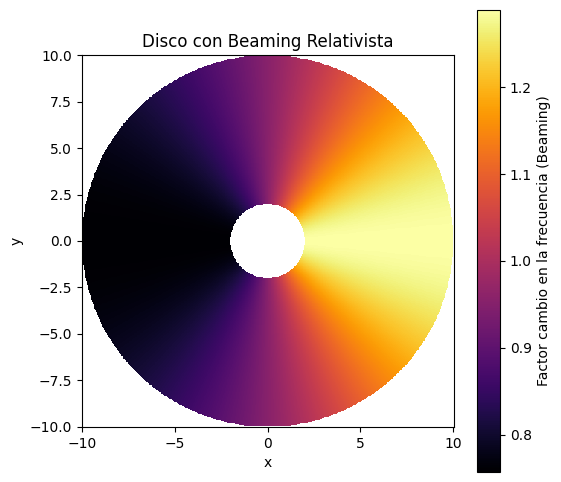

In [54]:
plt.figure(figsize=(6,6))
plt.pcolormesh(X, Y, factor_disco, shading='auto', cmap='inferno')
plt.colorbar(label='Factor cambio en la frecuencia (Beaming)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Disco con Beaming Relativista')
plt.gca().set_aspect('equal')
plt.show()

Ahora repetimos este experimento para diferentes valores de $\beta$ e $i$:

Parámetros del disco:

In [55]:
betas = [0.1, 0.3, 0.6]
inclinations = np.radians([0, 45, 80])

Rmax = 10
Rmin = 2
N = 400

Creación del disco:

In [56]:
x = np.linspace(-Rmax, Rmax, N)
y = np.linspace(-Rmax, Rmax, N)
X, Y = np.meshgrid(x, y)

R = np.sqrt(X**2 + Y**2)
phi = np.arctan2(Y, X)

mask = (R > Rmin) & (R < Rmax)

Creamos un bucle para repetir todo el proceso anterior para cada uno de los $\beta$ e $i$, y que una todas las gráficas en una figura

C:\Users\DTO\AppData\Local\Temp\ipykernel_10880\2700808896.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


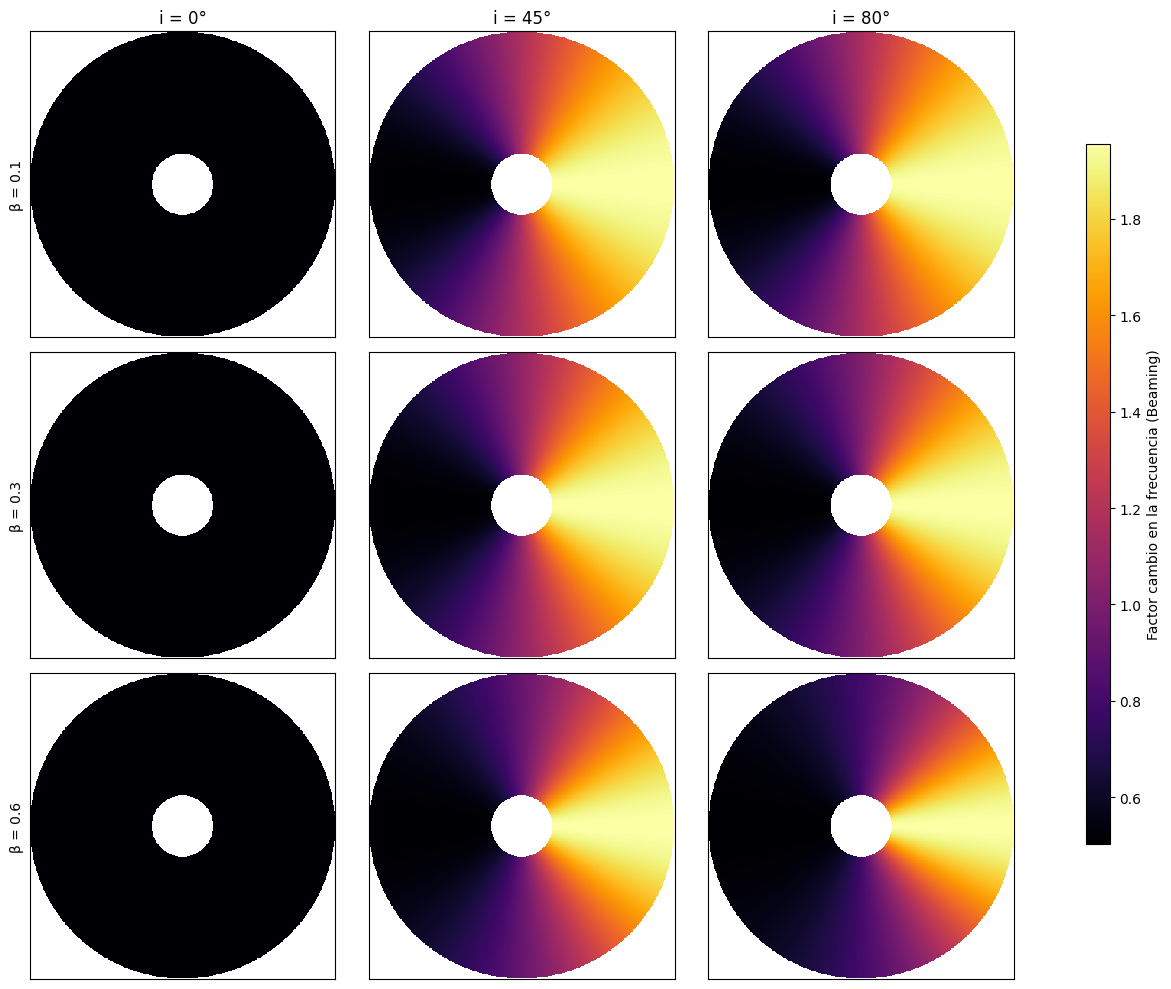

In [57]:
fig, axes = plt.subplots(len(betas), len(inclinations), figsize=(12,10))

for i, beta in enumerate(betas):
    gamma = 1 / np.sqrt(1 - beta**2)
    
    for j, inc in enumerate(inclinations):
        
        cos_theta = np.sin(inc) * np.cos(phi)
        
        factor_disco = 1 / (gamma * (1 - beta * cos_theta))
        
        factor_disco[~mask] = np.nan
        
        ax = axes[i, j]
        im = ax.pcolormesh(X, Y, factor_disco, shading='auto', cmap='inferno')
        
        ax.set_aspect('equal')
        ax.set_xticks([])
        ax.set_yticks([])
        
        if i == 0:
            ax.set_title(f"i = {np.degrees(inc):.0f}°")
        if j == 0:
            ax.set_ylabel(f"β = {beta}")

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  
fig.colorbar(im, cax=cbar_ax, label="Factor cambio en la frecuencia (Beaming)")

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

De la figura obtenida es importante notar que para $i=0^\circ$ se tiene $\cos(\theta)=0$ para todo el disco, lo que explica la ausencia de beaming e implica que el disco se observa con una frecuencia $\nu$ uniforme. Por el contrario, el caso extremo se daría cuando $i=90^\circ$, pues se daría la diferencia máxima entre regiones que se acercan y se alejan.

Se observa que cuando las partículas se mueven con su velocidad más hacia el observador, el factor de beaming es mucho mayor a cuando se mueven en dirección opuesta. Lo anterior conlleva a que las partículas que se acercan al observador se observarán con una frecuencia $\nu$ mayor y las que se alejan se observarán con una frecuencia $\nu$ menor.

Ahora es posible repetir el proceso anterior, pero esta vez con el fin de determinar cómo es el desplazamiento espectral a lo largo del disco. El desplazamiento espectral está dado por: $$z=\frac{1}{\delta(\theta , \beta)}-1$$

Entonces, luego de obtener el factor de beaming, es posible determinar el desplazamiento espectral para cada punto del disco. Para ello se utiliza el mismo código anterior y al final se calcula el desplazamiento espectral para cada punto. Este proceso se realiza para varios valores de $\beta$ e $i$ y se grafican los resultados en una figura.

Parámetros del disco:

In [58]:
betas = [0.1, 0.4, 0.7]
inclinations = np.radians([0, 45, 80])

Rmax = 10
Rmin = 2
N = 400

Creación del disco:

In [59]:
x = np.linspace(-Rmax, Rmax, N)
y = np.linspace(-Rmax, Rmax, N)
X, Y = np.meshgrid(x, y)

R = np.sqrt(X**2 + Y**2)
phi = np.arctan2(Y, X)

mask = (R > Rmin) & (R < Rmax)

Para visualizar mejor el desplazamiento espectral en la figura (desplazamiento al rojo y al azul), creamos un colormap personalizado donde los desplazamientos negativos sean azules, los positivos rojos y un desplazamiento nulo sea blanco.

In [60]:
colors = ["blue", "white", "red"]
astro_cmap = mcolors.LinearSegmentedColormap.from_list("astro_shift", colors)

Generamos la figura con los diferentes discos. Aplicamos el colormap personalizado para visualizar mejor el desplazamiento espectral en las gráficas

C:\Users\DTO\AppData\Local\Temp\ipykernel_10880\1960963790.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


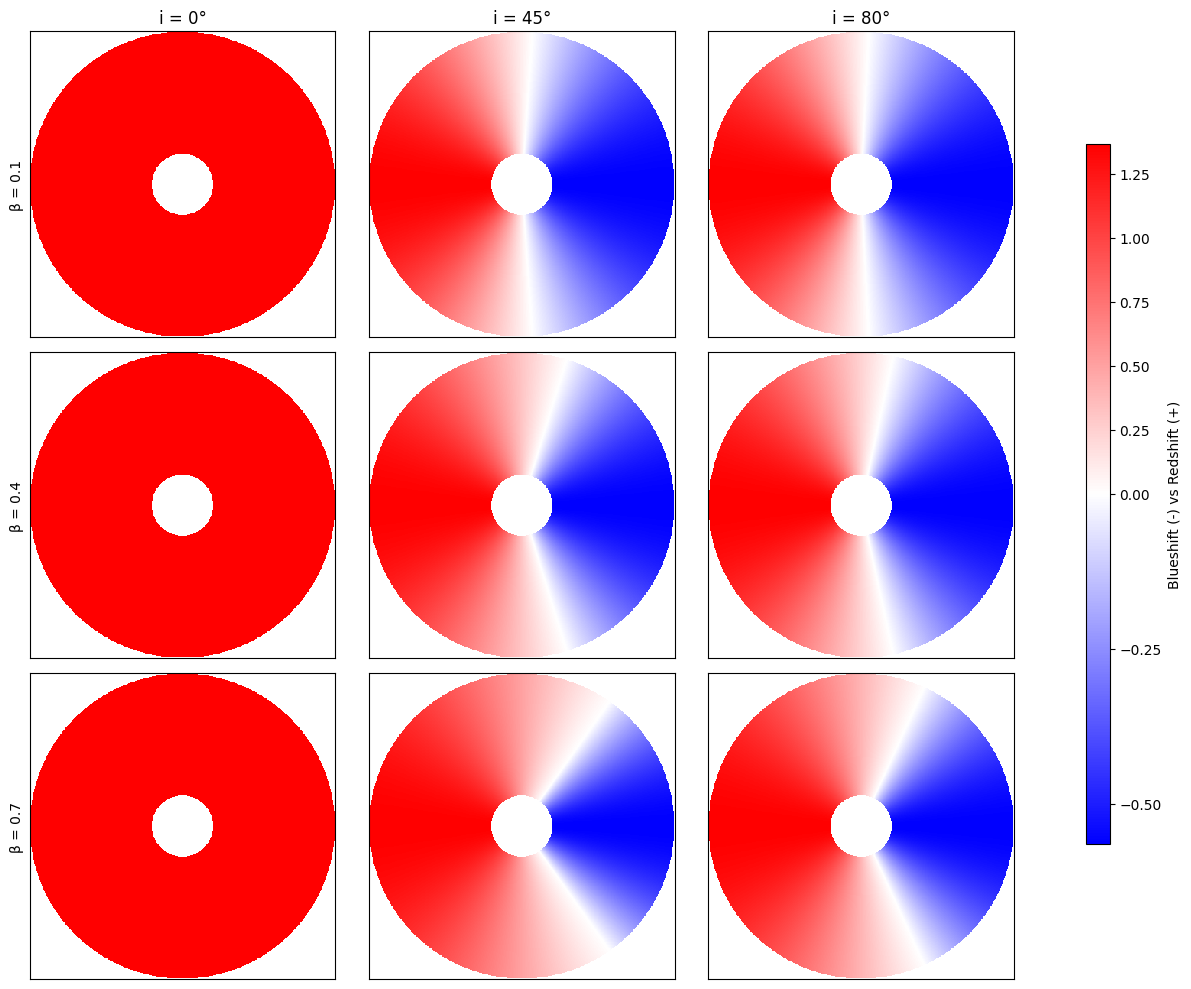

In [61]:
fig, axes = plt.subplots(len(betas), len(inclinations), figsize=(12, 10))

# Para guardar el rango global y que la escala sea consistente
all_data = []

for i, beta in enumerate(betas):
    for j, inc in enumerate(inclinations):
        cos_theta = np.sin(inc) * np.cos(phi)
        
        factor_disco = 1 / (gamma_factor(beta) * (1 - beta * cos_theta))
        z = 1/factor_disco - 1
        
        z[~mask] = np.nan
        ax = axes[i, j]
        
        # Configurar Normalización: el vcenter=0 garantiza que el blanco sea el neutro
        # Usamos los límites locales o globales. Aquí calculamos límites para cada subplot
        vmin, vmax = np.nanmin(z), np.nanmax(z)
        # Si el rango no incluye el 0 o es plano, evitamos error
        if vmin >= 0: vmin = -0.001 
        if vmax <= 0: vmax = 0.001
        
        norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
        
        im = ax.pcolormesh(X, Y, z, shading='auto', cmap=astro_cmap, norm=norm)
        
        ax.set_aspect('equal')
        ax.set_xticks([])
        ax.set_yticks([])
        
        if i == 0:
            ax.set_title(f"i = {np.degrees(inc):.0f}°")
        if j == 0:
            ax.set_ylabel(f"β = {beta}")

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  
fig.colorbar(im, cax=cbar_ax, label="Blueshift (-) vs Redshift (+)")

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

## **Jets**

Unidades para simular el jet

In [62]:
eps0 = const.eps0
UL = 100e3 # 100 km, simulando un disco de acreción alrededor de una estrella
UM = const.m_e

# Unidades relativistas c = 1 que implica c = UL/UT
UT = UL / const.c

# Unidades derivadas
UV = UL / UT
UA = UL / UT**2
UF = UM * UA

# Unidades gaussianas
UQ = UL * np.sqrt(UF * 4 * np.pi * eps0)
UE = UF / UQ
UB = UE / UV

C = 1

Tensor de Faraday para Campo Helicoidal

Campo Magnético Helicoidal:

$$B_r=0$$

$$B_z=B_0$$

$$B_\phi = \frac{B_1}{r}$$

Conversión a cartesianas:

$$B_x = B_r \cos(\phi) - B_\phi \sin(\phi)$$

$$B_y = B_r \sin(\phi) + B_\phi \cos(\phi)$$

$$B_z = B_z$$

In [63]:
def tensor_faraday_campo_helicoidal(B0, B1, x, y, z):
    Ex = Ey = Ez = 0
    Bx = By = 0
    
    r = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)
    
    Bx = -B1/r * np.sin(phi)
    By = B1/r * np.cos(phi)
    Bz = B0

    F = np.array([
        [0, -Ex, -Ey, -Ez],
        [Ex, 0, -Bz, By],
        [Ey, Bz, 0, -Bx],
        [Ez, -By, Bx, 0]
    ])
    return F

Ecuación Movimiento Relativista

In [64]:
def edm_relativista(tau, Ys, m, q, B0, B1):
    x0, x1, x2, x3, U0, U1, U2, U3 = Ys

    dx0_dtau = U0
    dx1_dtau = U1
    dx2_dtau = U2
    dx3_dtau = U3

    F = tensor_faraday_campo_helicoidal(B0, B1, x1, x2, x3)
    
    # U_nu = g_mu_nu * U^mu = diag(1, -1, -1, -1) * U^mu
    Usub = np.array([U0, -U1, -U2, -U3])

    f = q/C * F @ Usub

    dU0_dtau = f[0] / m 
    dU1_dtau = f[1] / m
    dU2_dtau = f[2] / m
    dU3_dtau = f[3] / m

    return np.array([dx0_dtau, dx1_dtau, dx2_dtau, dx3_dtau, dU0_dtau,
                        dU1_dtau, dU2_dtau, dU3_dtau])

Condiciones Iniciales

In [65]:
# En coordenadas temporales y espaciales
t0 = 0
r0 = np.array([1.0, 0.0, 0.0])
v0 = np.array([0.0, 0.2, 0.1])

# En coordenadas espaciotemporales
x0 = np.array([C*t0, r0[0], r0[1], r0[2]])
gamma0 = 1 / np.sqrt(1 - np.linalg.norm(v0)**2 / C**2)
U0 = np.array([gamma0, gamma0*v0[0], gamma0*v0[1], gamma0*v0[2]])

# Condiciones iniciales ahora si
Ys0 = np.concatenate((x0, U0))

In [66]:
m = 1
q = 1
B0 = 0.1
B1 = 2
taus = np.linspace(0, 300, 1000)
solucion = solve_ivp(
    edm_relativista,
    (taus[0], taus[-1]),
    Ys0,
    t_eval=taus,
    args=(m, q, B0, B1),
    method='Radau'
)

ts = solucion.y[0] / C
xs = solucion.y[1]
ys = solucion.y[2]
zs = solucion.y[3] 

In [67]:
fig = go.Figure(
    data=[
        go.Scatter3d(
            x=xs,
            y=ys,
            z=zs,
            mode='lines',
            line=dict(width=4, color=ts, colorscale='Viridis'),
            name='Trayectoria'
        )
    ]
)

fig.update_layout(
    scene=dict(
        xaxis_title='x',
        yaxis_title='y',
        zaxis_title='z',
        aspectmode='data'
    ),
    template='plotly_white'
)

fig.show()

## **Trayectoria de Partículas con Métrica de Schwarzschild y Kerr**

### Métrica de Schwarzschild

La Métrica de Schwarzschild está dada por:

$$
ds^2 = \left(1-\frac{2GM}{c^2 r} \right) c^2 dt^2 - \left(1- \frac{2GM}{c^2 r} \right)^{-1} dr^2 - r^2d\theta^2 - r^2 \sin^2(\theta) d\phi^2
$$

Primero se deben calcular los símbolos de Christoffel para esta métrica

In [68]:
G, M, c, T, r, theta, phi = sp.symbols('G M c T r theta phi')

Matriz con la métrica:

In [69]:
gmat = np.diag([1-2*G*M/(c**2*r), -1/(1-2*G*M/(c**2*r)), -r**2, -r**2*sp.sin(theta)**2])

Creamos el tensor métrico:

In [70]:
coordenadas = T, r, theta, phi
gmet = es.MetricTensor(gmat, coordenadas)
display(gmet.tensor())

[[-2*G*M/(c**2*r) + 1, 0, 0, 0], [0, -1/(-2*G*M/(c**2*r) + 1), 0, 0], [0, 0, -r**2, 0], [0, 0, 0, -r**2*sin(theta)**2]]

Símbolos de Christoffel a partir del tensor métrico:

In [71]:
Gab = es.ChristoffelSymbols.from_metric(gmet)
display(Gab.tensor())

[[[0, G*M/(r*(-2*G*M + c**2*r)), 0, 0], [G*M/(r*(-2*G*M + c**2*r)), 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]], [[-G*M*(2*G*M - c**2*r)/(c**4*r**3), 0, 0, 0], [0, G*M*(2*G*M - c**2*r)/(c**4*r**3*(-2*G*M/(c**2*r) + 1)**2), 0, 0], [0, 0, (2*G*M - c**2*r)/c**2, 0], [0, 0, 0, (2*G*M - c**2*r)*sin(theta)**2/c**2]], [[0, 0, 0, 0], [0, 0, 1/r, 0], [0, 1/r, 0, 0], [0, 0, 0, -sin(theta)*cos(theta)]], [[0, 0, 0, 0], [0, 0, 0, 1/r], [0, 0, 0, cos(theta)/sin(theta)], [0, 1/r, cos(theta)/sin(theta), 0]]]

Ahora se deben definir las ecuaciones de la geodésica

$$
\frac{d^2x^\sigma}{d\tau^2} = -\Gamma^\sigma_{\mu \nu} \dot{x}^\mu \dot{x}^\nu
$$

In [72]:
xpp = sp.symbols(r'\ddot{T} \ddot{r} \ddot{\theta} \ddot{\phi}')
xp = sp.symbols(r'\dot{T} \dot{r} \dot{\theta} \dot{\phi}')

for sigma in range(4):
    ecuacion = 0
    for mu in range(4):
        for nu in range(4):
            ecuacion += -Gab[sigma, mu, nu] * xp[mu] * xp[nu]

    ecuacion = sp.Eq(xpp[sigma],ecuacion)
    display(ecuacion)

Eq(\ddot{T}, -2*G*M*\dot{T}*\dot{r}/(r*(-2*G*M + c**2*r)))

Eq(\ddot{r}, G*M*\dot{T}**2*(2*G*M - c**2*r)/(c**4*r**3) - G*M*\dot{r}**2*(2*G*M - c**2*r)/(c**4*r**3*(-2*G*M/(c**2*r) + 1)**2) - \dot{\phi}**2*(2*G*M - c**2*r)*sin(theta)**2/c**2 - \dot{\theta}**2*(2*G*M - c**2*r)/c**2)

Eq(\ddot{\theta}, \dot{\phi}**2*sin(theta)*cos(theta) - 2*\dot{\theta}*\dot{r}/r)

Eq(\ddot{\phi}, -2*\dot{\phi}*\dot{\theta}*cos(theta)/sin(theta) - 2*\dot{\phi}*\dot{r}/r)

In [73]:
def edg_schwarzschild(tau, Ys, G, M, c):
    t, r, theta, phi, Ut, Ur, Utheta, Uphi = Ys

    rs = 2 * G * M / c**2  # radio de Schwarzschild

    # Derivadas de las coordenadas
    dT_dtau = Ut
    dr_dtau = Ur
    dtheta_dtau = Utheta
    dphi_dtau = Uphi

    # Ecuaciones geodésicas: d²x^σ/dτ² = -Γ^σ_{μν} ẋ^μ ẋ^ν
    # Γ^0_{01} = Γ^0_{10} = G*M / (r*(-2*G*M + c²*r))
    dUt_dtau = -2 * G * M / (r * (-2 * G * M + c**2 * r)) * Ut * Ur

    # Γ^1_{00}, Γ^1_{11}, Γ^1_{22}, Γ^1_{33}
    dUr_dtau = (- (- G * M * (2 * G * M - c**2 * r) / (c**4 * r**3)) * Ut**2
                - G * M * (2 * G * M - c**2 * r) / (c**4 * r**3 * (1 - rs/r)**2) * Ur**2
                - (2 * G * M - c**2 * r) / c**2 * Utheta**2
                - (2 * G * M - c**2 * r) / c**2 * np.sin(theta)**2 * Uphi**2)

    # Γ^2_{12} = Γ^2_{21} = 1/r,  Γ^2_{33} = -sin(θ)cos(θ)
    dUtheta_dtau = (-2 / r * Ur * Utheta
                   + np.sin(theta) * np.cos(theta) * Uphi**2)

    # Γ^3_{13} = Γ^3_{31} = 1/r,  Γ^3_{23} = Γ^3_{32} = cos(θ)/sin(θ)
    dUphi_dtau = (-2 / r * Ur * Uphi
                 - 2 * np.cos(theta) / np.sin(theta) * Utheta * Uphi)

    return [dT_dtau, dr_dtau, dtheta_dtau, dphi_dtau,
            dUt_dtau, dUr_dtau, dUtheta_dtau, dUphi_dtau]

Solución a las ecuaciones de la geodésica

### Métrica de Kerr

La métrica de Kerr está dada por:

$$
ds^2 = \left(1 - \frac{2GMr}{c^2\rho^2}\right) c^2 dt^2 
+ \frac{4GMr a\sin^2\theta}{c^2\rho^2} \, c \, dt \, d\phi 
- \frac{\rho^2}{\Delta} dr^2 
- \rho^2 d\theta^2 
- \left(r^2 + a^2 + \frac{2GMr a^2\sin^2\theta}{c^2\rho^2}\right) \sin^2\theta \, d\phi^2
$$

Tomando:

$$
\rho^2 = r^2 + a^2\cos^2\theta, \qquad 
$$
$$
\Delta = r^2 - \frac{2GM}{c^2}r + a^2, \qquad 
$$
$$
a = \frac{J}{Mc}
$$

Definimos los símbolos en sympy:

In [ ]:
G, M, c = sp.symbols('G M c')
T, r, teta, fi = sp.symbols('T r theta phi')
a = sp.symbols('a')

# Definimos parámetros
rho2 = r**2 + a**2*sp.cos(teta)**2
delta = r**2 - 2*G*M*r/c**2 + a**2

Debido al término $dtd\phi$, la métrica no es diagonal sino que es de la forma:

$$
g_{\mu\nu} = 
\begin{pmatrix}
g_{TT} & 0 & 0 & g_{T\phi} \\[12pt]
0 & g_{rr} & 0 & 0 \\[12pt]
0 & 0 & g_{\theta\theta} & 0 \\[12pt]
g_{T\phi} & 0 & 0 & g_{\phi\phi}
\end{pmatrix}
$$

Donde $g_{tt} = 1 - \frac{2GM}{c^2} \frac{r}{\rho^2}$, $g_{t\phi} = \frac{2GMr a \sin^2\theta}{c\,\rho^2}$, $g_{rr} = -\frac{\rho^2}{\Delta}$, $g_{\theta\theta} = -\rho^2$ y $g_{\phi\phi} = -\left(r^2 + a^2 + \frac{2GM}{c^2} \frac{r a^2 \sin^2\theta}{\rho^2}\right) \sin^2\theta$

Definimos la métrica para luego calcular los símbolos de Christoffel:

In [ ]:
gTT = 1 - 2*G*M*r/(c**2*rho2)
grr = -rho2/delta
gthetatheta = -rho2
gphiphi = -(r**2 + a**2 + 2*G*M*a**2*r*sp.sin(teta)**2/(c**2*rho2))*sp.sin(teta)**2
gTphi = 2*G*M*a*r*sp.sin(teta)**2/(c**2*rho2)

gmat = np.array([[gTT, 0, 0, gTphi], [0, grr, 0, 0], [0, 0, gthetatheta, 0], [gTphi, 0, 0, gphiphi]])
coordenadas = T, r, teta, fi

In [ ]:
gmet = es.MetricTensor(gmat, coordenadas)
display(gmet.tensor())

In [ ]:
Gab = es.ChristoffelSymbols.from_metric(gmet)
display(Gab.tensor())

Ecuaciones de la geodésica: $$\frac{d^2x^\mu}{d\tau^2} = - \Gamma ^\mu_{\alpha \beta} \frac{dx^\alpha}{d\tau}\frac{dx^\beta}{d\tau}$$

In [ ]:
xpp = sp.symbols(r'\ddot{T} \ddot{r} \ddot{\theta} \ddot{\phi}')
xp = sp.symbols(r'\dot{T} \dot{r} \dot{\theta} \dot{\phi}')

for sigma in range(4):
    ecuacion = 0
    for mu in range(4):
        for nu in range(4):
            ecuacion += -Gab[sigma, mu, nu] * xp[mu] * xp[nu]

    ecuacion = sp.Eq(xpp[sigma],ecuacion)
    display(ecuacion)

In [ ]:
def edg_kerr(tau, Ys, G_val, M_val, c_val, a_val):
    T, r_val, theta_val, phi_val, Ut, Ur, Utheta, Uphi = Ys

    # Ecuaciones cinemáticas
    dT_dtau = Ut
    dr_dtau = Ur
    dtheta_dtau = Utheta
    dphi_dtau = Uphi

    # Lambdify SOLO una vez
    if not hasattr(edg_kerr, "_Gamma_func"):

        edg_kerr._Gamma_func = sp.lambdify(
            (r, teta, G, M, c, a),
            Gab.tensor(),
            "numpy"
        )

    # Evaluar Christoffel
    Gamma_num = edg_kerr._Gamma_func(
        r_val,
        theta_val,
        G_val,
        M_val,
        c_val,
        a_val
    )

    U = np.array([Ut, Ur, Utheta, Uphi])

    dU = np.zeros(4)

    # Ecuaciones geodésicas
    for alpha in range(4):

        suma = 0.0

        for mu in range(4):
            for nu in range(4):

                suma += (
                    -Gamma_num[alpha, mu, nu]
                    * U[mu]
                    * U[nu]
                )

        dU[alpha] = suma

    return [
        dT_dtau,
        dr_dtau,
        dtheta_dtau,
        dphi_dtau,
        dU[0],
        dU[1],
        dU[2],
        dU[3]
    ]

Solución a las ecuaciones de la geodésica: